## Imports

In [37]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from tqdm import trange
from collections import defaultdict
import math
import random
import itertools
import sentencepiece as spm
import tempfile
import re
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import os
import subprocess
from pathlib import Path


import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

In [38]:
df_full = pd.read_csv('../data/full_data_non_null.csv')
df_full["timestamp"] = pd.to_datetime(df_full["timestamp"])

df_full = df_full[df_full['timestamp'] >= '2016-01-01'] # Filter out data before 2016-01-01

## XPLR

### Datatype

In [39]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 263165 entries, 19864 to 283028
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   timestamp                   263165 non-null  datetime64[us]
 1   temperature_2m              263165 non-null  float64       
 2   relative_humidity_2m        263165 non-null  float64       
 3   dew_point_2m                263165 non-null  float64       
 4   apparent_temperature        263165 non-null  float64       
 5   precipitation               263165 non-null  float64       
 6   rain                        263165 non-null  float64       
 7   snowfall                    263165 non-null  float64       
 8   snow_depth                  263165 non-null  float64       
 9   weather_code                263165 non-null  float64       
 10  pressure_msl                263165 non-null  float64       
 11  surface_pressure            263165 non-null  f

Note : 
1. Drop hour, day, month, year as they are dupes with timestamp
2. We dont drop is_day because it may not contained in timestamp (e.g. different location, different sunrise)

In [40]:
df_full = df_full.drop(columns=["hour", "day", "month", "year"])

In [41]:
# Unique values per column
for col in df_full.columns:
    print(f"{col}: {df_full[col].nunique()}")

timestamp: 17544
temperature_2m: 21958
relative_humidity_2m: 240045
dew_point_2m: 19902
apparent_temperature: 261909
precipitation: 139
rain: 186
snowfall: 45
snow_depth: 80
weather_code: 13
pressure_msl: 724
surface_pressure: 199866
cloud_cover: 923
cloud_cover_low: 101
cloud_cover_mid: 101
cloud_cover_high: 101
et0_fao_evapotranspiration: 213366
vapour_pressure_deficit: 241215
wind_speed_10m: 3668
wind_direction_10m: 12537
wind_gusts_10m: 299
soil_temperature_0_to_7cm: 18920
soil_temperature_7_to_28cm: 14285
soil_moisture_0_to_7cm: 564
soil_moisture_7_to_28cm: 485
is_day: 2
sunshine_duration: 21968
shortwave_radiation: 1062
direct_radiation: 943
diffuse_radiation: 448
direct_normal_irradiance: 112838
terrestrial_radiation: 122319
location_id: 15
y: 237194
latitude: 13
longitude: 13
location: 12
cluster_size: 1


Note : Drop cluster_size as it only contain 1 value

In [ ]:
df_full = df_full.drop(columns=["cluster_size"])

### location_id vs location misscount

In [42]:
df_full["test_loc"] = df_full["location_id"] + "_" + df_full["location"]

# Select non-numeric columns
non_numeric_cols = df_full.select_dtypes(exclude=['number', 'datetime']).columns

# Print unique values for each non-numeric column
for col in non_numeric_cols:
    print(f"\nColumn: {col}")
    print(df_full[col].unique())


Column: location_id
<ArrowStringArray>
['gcpvj6btgb1d', 'u1krw2n6k8f6', '9q9p3yhbxx8t', 'gcjszrm15xgd',
 'djn4hpuvh93f', 'gcpuvr295zcd', '9v6kpy7zsbvx', 'gcpvj4cmfb0f',
 'f244mkkywjsv', 'dqcjr9e0bvw4', '9zvxvu65krxz', 'dr4vs1mpgc4v',
 'dr99e3temvdj', 'f244jquzyjkb', '9tbqhgzj9gwc']
Length: 15, dtype: str

Column: location
<ArrowStringArray>
[                 'London, UK',               'Groningen, NL',
    'Oakland, California, USA',                 'Cardiff, UK',
       'Orlando, Florida, USA',          'Austin, Texas, USA',
                  'Ottawa, CA',          'Washington DC, USA',
 'Minneapolis, Minnesota, USA',  'Princeton, New Jersey, USA',
       'Ithaca, New York, USA',       'Phoenix, Arizona, USA']
Length: 12, dtype: str

Column: test_loc
<ArrowStringArray>
[                 'gcpvj6btgb1d_London, UK',
               'u1krw2n6k8f6_Groningen, NL',
    '9q9p3yhbxx8t_Oakland, California, USA',
                 'gcjszrm15xgd_Cardiff, UK',
       'djn4hpuvh93f_Orlando, Florida,

Note: London, UK has three location_id s and Ottawa, CA has two location_id s, so location will be ignored and location_id will be used instead

In [43]:
df_full = df_full.drop(columns=["location"])

### Unknown Timestamp

In [44]:
# unique values
locations = df_full['location_id'].unique()
timestamps = df_full['timestamp'].unique()

# full combination
full_index = pd.MultiIndex.from_product(
    [locations, timestamps],
    names=['location_id', 'timestamp']
)

full_df = full_index.to_frame(index=False)

# find missing combinations
merged = full_df.merge(
    df_full[['location_id', 'timestamp']],
    on=['location_id', 'timestamp'],
    how='left',
    indicator=True
)

missing = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

print(len(missing))

0


Note : No Missing Targets

### Time Range

In [45]:
df_sorted = df_full.sort_values(['location_id', 'timestamp'])

df_sorted['time_diff'] = df_sorted.groupby('location_id')['timestamp'].diff()

print(df_sorted[['location_id', 'timestamp', 'time_diff']])
print(f"Unique time differences: {df_sorted['time_diff'].unique()}")  

         location_id           timestamp       time_diff
19866   9q9p3yhbxx8t 2016-01-01 00:00:00             NaT
19885   9q9p3yhbxx8t 2016-01-01 01:00:00 0 days 01:00:00
19901   9q9p3yhbxx8t 2016-01-01 02:00:00 0 days 01:00:00
19917   9q9p3yhbxx8t 2016-01-01 03:00:00 0 days 01:00:00
19926   9q9p3yhbxx8t 2016-01-01 04:00:00 0 days 01:00:00
...              ...                 ...             ...
282964  u1krw2n6k8f6 2017-12-31 20:00:00 0 days 01:00:00
282987  u1krw2n6k8f6 2017-12-31 21:00:00 0 days 01:00:00
283000  u1krw2n6k8f6 2017-12-31 22:00:00 0 days 01:00:00
283001  u1krw2n6k8f6 2017-12-31 22:00:00 0 days 00:00:00
283013  u1krw2n6k8f6 2017-12-31 23:00:00 0 days 01:00:00

[263165 rows x 3 columns]
Unique time differences: <TimedeltaArray>
[NaT, '0 days 01:00:00', '0 days 00:00:00']
Length: 3, dtype: timedelta64[us]


In [46]:
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

print("Min timestamp:", df_full['timestamp'].min())
print("Max timestamp:", df_full['timestamp'].max())

Min timestamp: 2016-01-01 00:00:00
Max timestamp: 2017-12-31 23:00:00


Note : Delta 1 hours from 2011-01-01 01:00:00 to 2017-12-31 23:00:00

### Plot y per timestamp

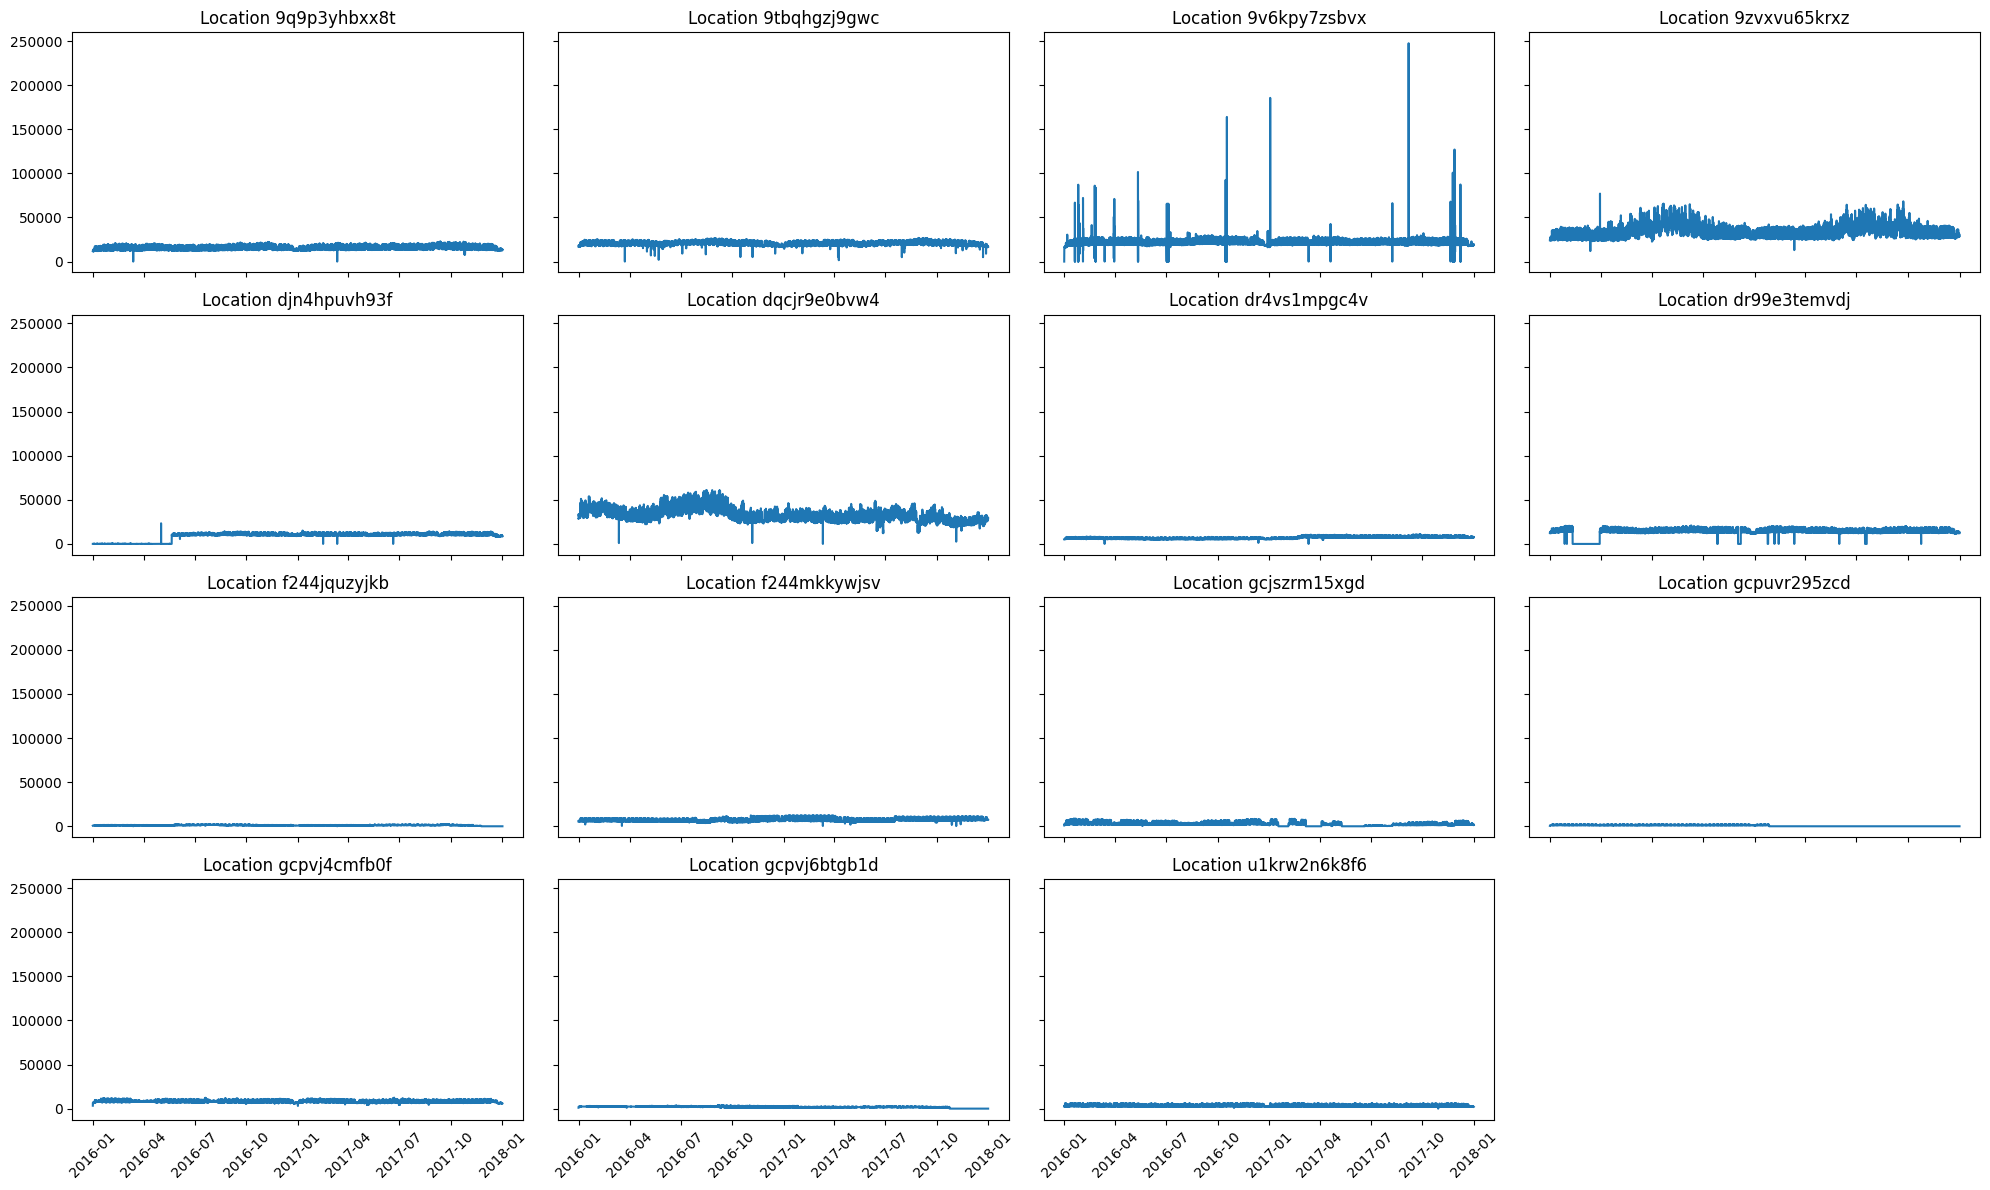

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Sort properly
df_full = df_full.sort_values(['location_id', 'timestamp'])

# Get unique locations (limit to 16 for 4x4 grid)
locations = df_full['location_id'].unique()[:16]

fig, axes = plt.subplots(4, 4, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]
    
    subset = df_full[df_full['location_id'] == loc]
    
    ax.plot(subset['timestamp'], subset['y'])
    ax.set_title(f'Location {loc}')
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots if <16 locations
for j in range(len(locations), 16):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Corr Heatmap

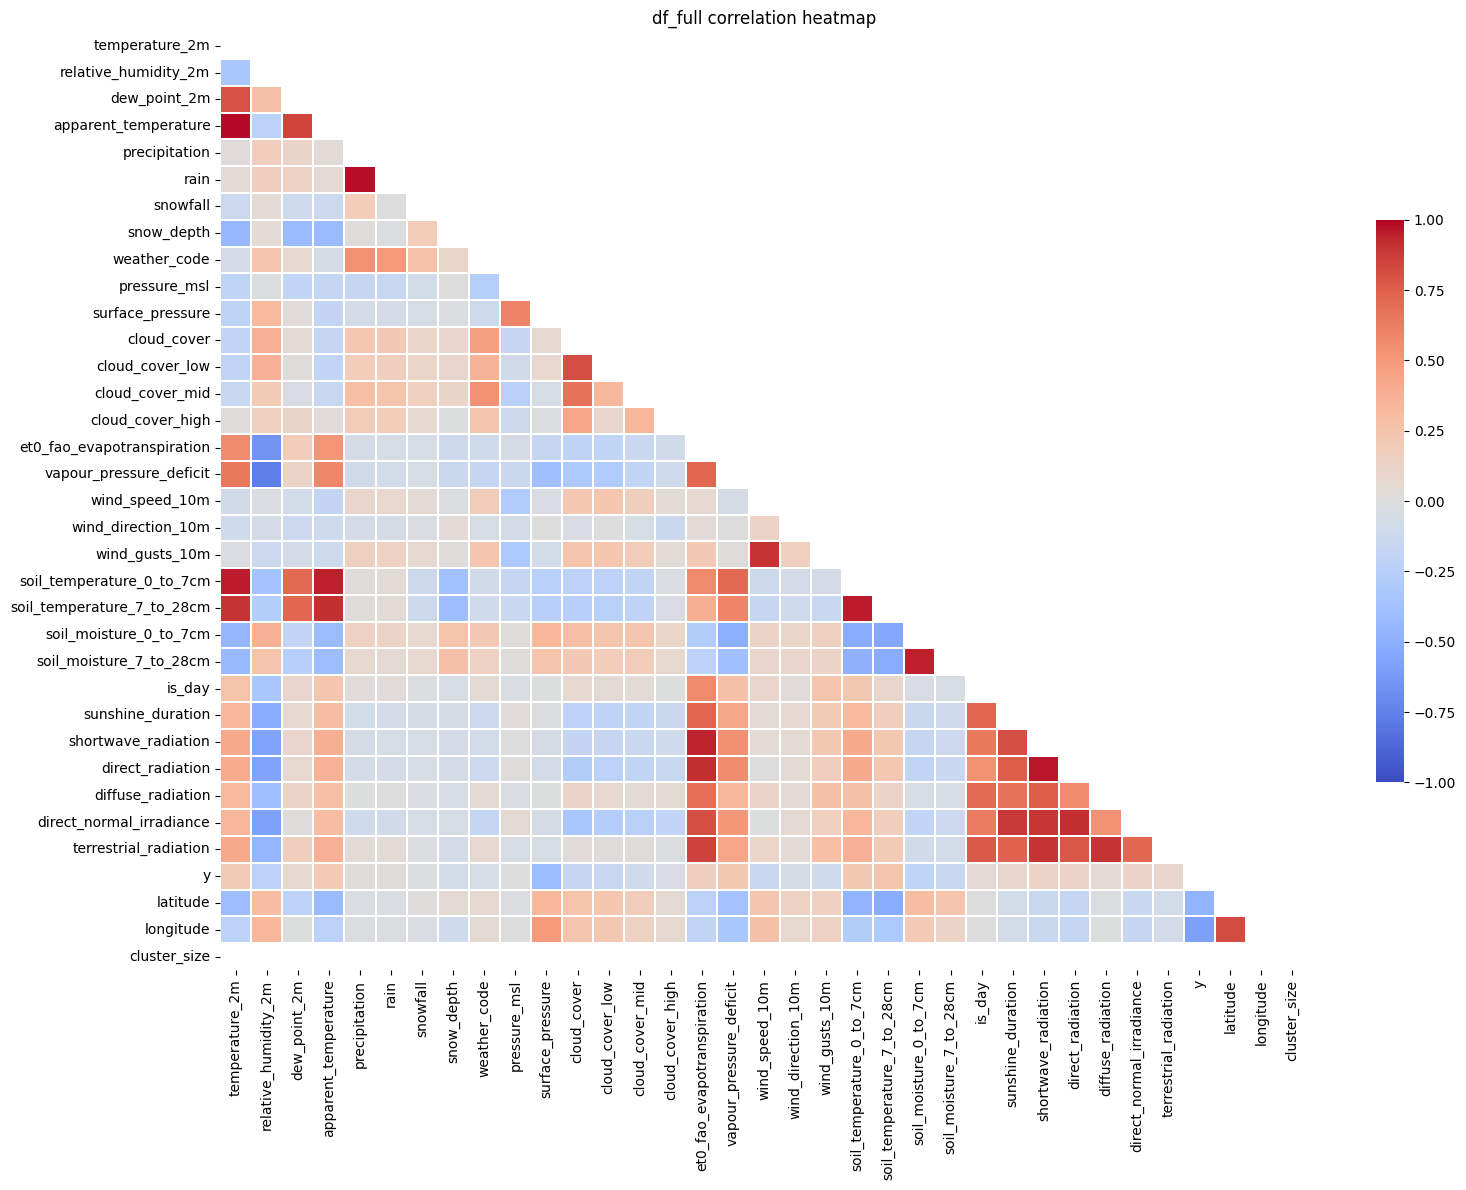

In [48]:
import seaborn as sns
import numpy as np

num_df = df_full.select_dtypes(include=[np.number])
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.25, cbar_kws={"shrink": 0.6})
plt.title("df_full correlation heatmap")
plt.tight_layout()
plt.show()

In [49]:
# Correlations of numeric columns (reuse corr if available)
num_cols = df_full.select_dtypes(include=[np.number]).columns
corr = df_full[num_cols].corr()

# Correlations with target 'y', sorted by absolute value descending
y_corr = corr['y'].drop('y')
y_sorted = y_corr.reindex(y_corr.abs().sort_values(ascending=False).index)
print("Correlations with 'y' (sorted by absolute value):")
print(y_sorted)

# Top correlated pairs overall (exclude self-correlations), sorted by absolute correlation
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
pairs.columns = ['var1', 'var2', 'corr']
pairs_sorted = pairs.reindex(pairs['corr'].abs().sort_values(ascending=False).index)
print("\nTop correlated variable pairs (by absolute correlation):")
print(pairs_sorted.head(20).to_string(index=False))

Correlations with 'y' (sorted by absolute value):
longitude                    -0.591629
latitude                     -0.476130
surface_pressure             -0.415918
soil_temperature_7_to_28cm    0.243453
relative_humidity_2m         -0.227107
vapour_pressure_deficit       0.226183
soil_temperature_0_to_7cm     0.222018
apparent_temperature          0.204537
soil_moisture_0_to_7cm       -0.199821
temperature_2m                0.198102
et0_fao_evapotranspiration    0.164869
cloud_cover                  -0.162181
soil_moisture_7_to_28cm      -0.149862
cloud_cover_low              -0.149196
wind_speed_10m               -0.147942
direct_radiation              0.131326
direct_normal_irradiance      0.127498
shortwave_radiation           0.118854
cloud_cover_mid              -0.100812
wind_gusts_10m               -0.094931
terrestrial_radiation         0.090583
sunshine_duration             0.089502
snow_depth                   -0.082837
dew_point_2m                  0.064208
wind_direction